# Developmental Heart — Concatenation

Combine three Stereo-seq bin50 samples (exported from Seurat) into a single AnnData:

| Sample | Stage |
|--------|-------|
| `GSM9019992_sample_P0_p_3` | P0 |
| `GSM9019993_sample_P7_p_1` | P7 |
| `GSM9019995_sample_Adult_B2` | Adult |

Each file already carries SCT-normalized data in `X`, raw counts in `layers["counts"]`, per-sample PCA/UMAP in `obsm`, and Seurat clusters in `obs`. This notebook concatenates them, adds stage labels, re-runs a joint processing pass (normalize → HVG → PCA → UMAP → Leiden), and saves the result.

In [ ]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault("KMP_WARNINGS", "0")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

pd.set_option("display.max_columns", 120)

PROJECT_ROOT = Path("/Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling")
DATA_ROOT = Path("/Volumes/processing2/dev-heart")

SAMPLES = {
    "P0":    DATA_ROOT / "GSM9019992_sample_P0_p_3_bin50_seurat.h5ad",
    "P7":    DATA_ROOT / "GSM9019993_sample_P7_p_1_bin50_seurat.h5ad",
    "Adult": DATA_ROOT / "GSM9019995_sample_Adult_B2_bin50_seurat.h5ad",
}

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "dev-heart"
OUTPUT_PATH = OUTPUT_DIR / "dev_heart_combined.h5ad"

WRITE_OUTPUT = True

for stage, p in SAMPLES.items():
    print(f"  {stage}: {p.name}  exists={p.exists()}")

/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/chrislangseth/miniforge3/envs/cellcharter/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


  P0: GSM9019992_sample_P0_p_3_bin50_seurat.h5ad  exists=True
  P7: GSM9019993_sample_P7_p_1_bin50_seurat.h5ad  exists=True
  Adult: GSM9019995_sample_Adult_B2_bin50_seurat.h5ad  exists=True


## Load and inspect individual samples

In [2]:
adatas = {}
for stage, path in SAMPLES.items():
    a = ad.read_h5ad(path)
    a.obs["stage"] = pd.Categorical([stage] * a.n_obs, categories=["P0", "P7", "Adult"], ordered=True)
    a.obs["sample_id"] = a.obs["orig.ident"].astype(str)
    a.var_names_make_unique()
    a.obs_names_make_unique()
    adatas[stage] = a
    print(f"{stage:6s}  {a.n_obs:>6,} spots x {a.n_vars:>6,} genes   clusters: {sorted(a.obs['seurat_clusters'].unique())}")

print(f"\nTotal spots: {sum(a.n_obs for a in adatas.values()):,}")

P0      25,458 spots x 19,758 genes   clusters: ['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']
P7      41,005 spots x 18,858 genes   clusters: ['0', '1', '10', '11', '12', '13', '14', '2', '3', '4', '5', '6', '7', '8', '9']
Adult   42,034 spots x 20,959 genes   clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '2', '3', '4', '5', '6', '7', '8', '9']

Total spots: 108,497


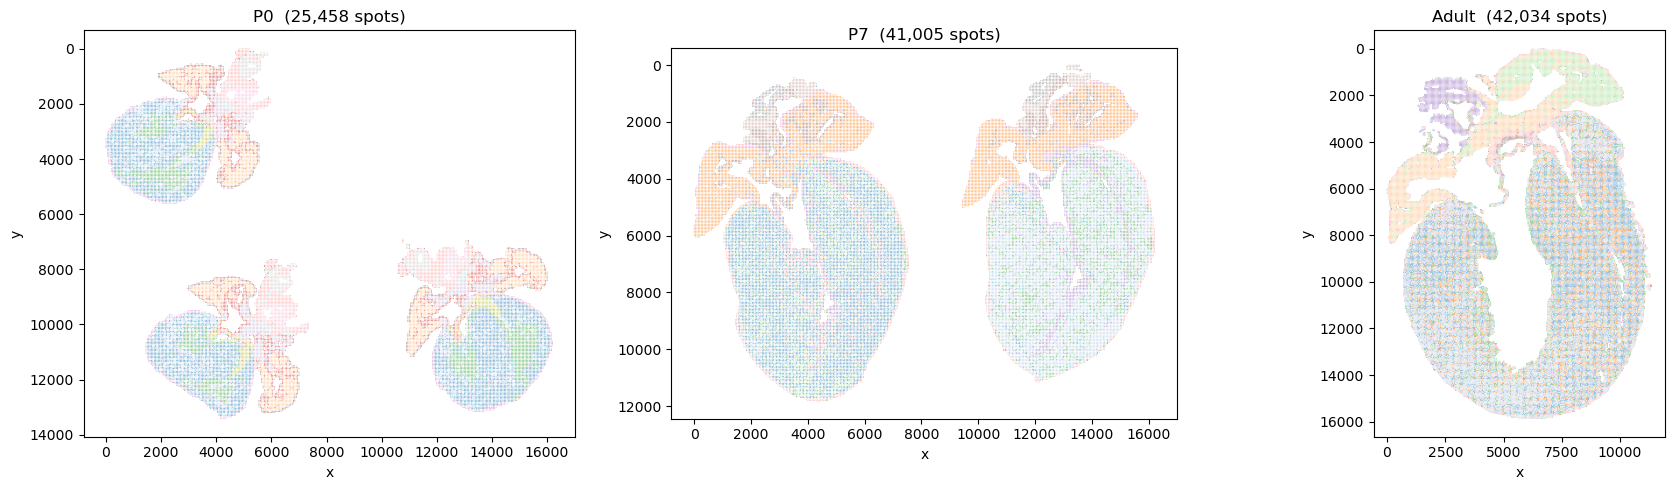

In [3]:
# Per-sample spatial overview using the Seurat clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (stage, a) in zip(axes, adatas.items()):
    coords = a.obsm["spatial"]
    sc_cat = a.obs["seurat_clusters"].astype("category")
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=sc_cat.cat.codes, cmap="tab20", s=0.3, linewidths=0)
    ax.set_title(f"{stage}  ({a.n_obs:,} spots)")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Concatenate

Use raw counts as `X` in the merged object (the per-sample SCT normalization is not comparable across samples). The Seurat clusters and per-sample embeddings are kept in `obs` for reference but will not drive downstream analysis.

In [9]:
adatas

{'P0': AnnData object with n_obs × n_vars = 25458 × 19758
     obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'stage', 'sample_id'
     uns: 'X_name'
     obsm: 'pca', 'spatial', 'umap'
     layers: 'counts',
 'P7': AnnData object with n_obs × n_vars = 41005 × 18858
     obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'stage', 'sample_id'
     uns: 'X_name'
     obsm: 'pca', 'spatial', 'umap'
     layers: 'counts',
 'Adult': AnnData object with n_obs × n_vars = 42034 × 20959
     obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'stage', 'sample_id'
     uns: 'X_name'
     obsm: 'pca', 'spatial', 'umap'
     layers: 'counts'}

In [11]:
adatas['P0'].obs["stage"]  

sample_P0_p_3:18700_15000    P0
sample_P0_p_3:17950_14600    P0
sample_P0_p_3:15100_15550    P0
sample_P0_p_3:19150_14850    P0
sample_P0_p_3:15250_14450    P0
                             ..
sample_P0_p_3:8550_15150     P0
sample_P0_p_3:8350_15450     P0
sample_P0_p_3:10750_17100    P0
sample_P0_p_3:9300_14800     P0
sample_P0_p_3:10400_19600    P0
Name: stage, Length: 25458, dtype: category
Categories (3, object): ['P0' < 'P7' < 'Adult']

In [17]:
# Swap raw counts into X before concatenation
for stage, a in adatas.items():
    a.X = a.layers["counts"].copy()

adata = ad.concat(
    adatas,
    label="stage",
    merge="same",
    join="inner",
    index_unique="-",
)

# Restore the ordered categorical for stage
adata.obs["stage"] = pd.Categorical(adata.obs["stage"], categories=["P0", "P7", "Adult"], ordered=True)

adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)
adata.obs["stage"].value_counts()

AnnData object with n_obs × n_vars = 108497 × 17937
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'stage', 'sample_id'
    obsm: 'pca', 'spatial', 'umap'
    layers: 'counts'


stage
Adult    42034
P7       41005
P0       25458
Name: count, dtype: int64

In [18]:
adata.X.max()

np.float64(1959.0)

In [19]:
adata.write('/Users/chrislangseth/Downloads/dev-heart-concatenated.h5ad')

In [20]:
adata = sc.read_h5ad('/Users/chrislangseth/Downloads/dev-heart-concatenated.h5ad')

## QC

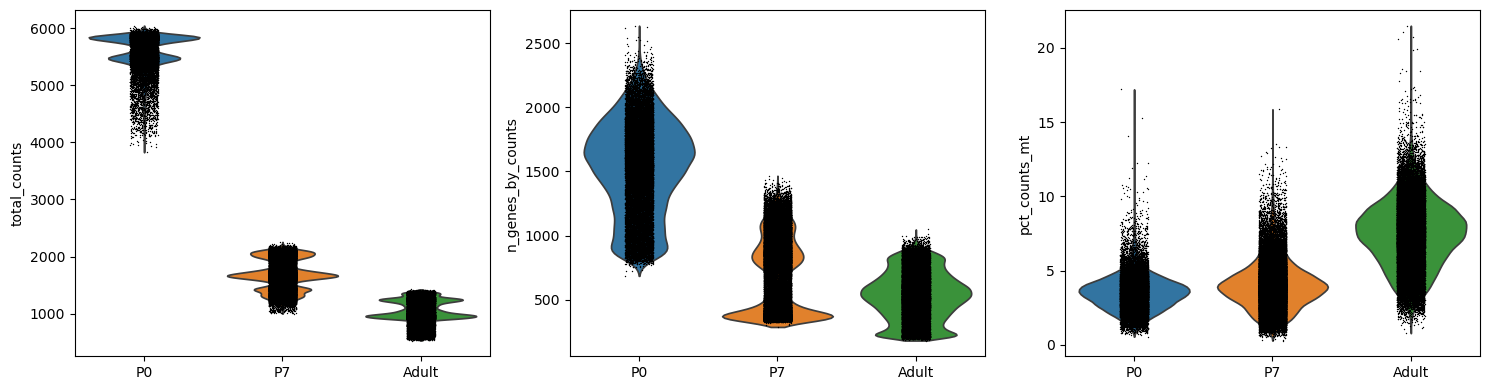

,total_counts,n_genes_by_counts,pct_counts_mt
stage,,,
P0,5647.0,1573.0,3.517766
P7,1669.0,747.0,3.913043
Adult,1041.5,538.0,7.558392


In [21]:
adata.var["mt"] = adata.var_names.str.startswith("mt-") | adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["total_counts", "n_genes_by_counts", "pct_counts_mt"]):
    sc.pl.violin(adata, col, groupby="stage", ax=ax, show=False, rotation=0)
plt.tight_layout()
plt.show()

adata.obs.groupby("stage", observed=False)[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].median()

## Normalize and process (joint)

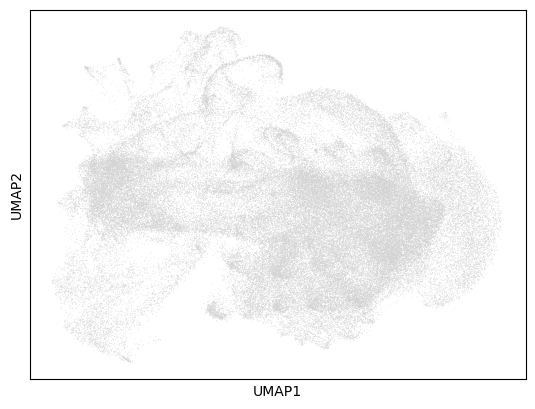

In [23]:
sc.pl.umap(adata)

In [24]:
sc.pp.filter_genes(adata, min_counts=3)
sc.pp.filter_cells(adata, min_counts=3)
print(f"After filtering: {adata.n_obs:,} spots x {adata.n_vars:,} genes")

adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata.copy()

n_top_genes = min(2000, adata.n_vars)
sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor="seurat", subset=True)

sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(30, adata.obsm["X_pca"].shape[1]))
sc.tl.umap(adata, min_dist=0.3)

adata

After filtering: 108,497 spots x 17,937 genes


AnnData object with n_obs × n_vars = 108497 × 2000
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'stage', 'sample_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'stage_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'pca', 'spatial', 'umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## Visualization

In [26]:
adata.obs

,orig.ident,nCount_Spatial,nFeature_Spatial,cell,x,y,nCount_SCT,nFeature_SCT,SCT_snn_res.0.4,seurat_clusters,stage,sample_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_counts
sample_P0_p_3:18700_15000-P0,sample_P0_p_3,5743.0,1598,sample_P0_p_3:18700_15000,18700.0,15000.0,5714.0,1598,4,4,P0,sample_P0_p_3,1594,5706.0,158.0,2.769015,5706.0
sample_P0_p_3:17950_14600-P0,sample_P0_p_3,5154.0,1703,sample_P0_p_3:17950_14600,17950.0,14600.0,5422.0,1702,2,2,P0,sample_P0_p_3,1698,5416.0,184.0,3.397341,5416.0
sample_P0_p_3:15100_15550-P0,sample_P0_p_3,5211.0,1675,sample_P0_p_3:15100_15550,15100.0,15550.0,5439.0,1675,2,2,P0,sample_P0_p_3,1669,5431.0,212.0,3.903517,5431.0
sample_P0_p_3:19150_14850-P0,sample_P0_p_3,9107.0,2281,sample_P0_p_3:19150_14850,19150.0,14850.0,5834.0,2241,2,2,P0,sample_P0_p_3,2236,5827.0,193.0,3.312167,5827.0
sample_P0_p_3:15250_14450-P0,sample_P0_p_3,2754.0,1067,sample_P0_p_3:15250_14450,15250.0,14450.0,5452.0,1146,10,10,P0,sample_P0_p_3,1137,5369.0,129.0,2.402682,5369.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample_Adult_B2:11100_10000-Adult,sample_Adult_B2,1.0,1,sample_Adult_B2:11100_10000,11100.0,10000.0,534.0,273,4,4,Adult,sample_Adult_B2,272,533.0,87.0,16.322702,533.0
sample_Adult_B2:5550_5300-Adult,sample_Adult_B2,1.0,1,sample_Adult_B2:5550_5300,5550.0,5300.0,535.0,273,4,4,Adult,sample_Adult_B2,272,534.0,88.0,16.479401,534.0
sample_Adult_B2:9550_1900-Adult,sample_Adult_B2,4.0,1,sample_Adult_B2:9550_1900,9550.0,1900.0,536.0,264,1,1,Adult,sample_Adult_B2,263,535.0,115.0,21.495327,535.0
sample_Adult_B2:7800_2850-Adult,sample_Adult_B2,1.0,1,sample_Adult_B2:7800_2850,7800.0,2850.0,535.0,273,4,4,Adult,sample_Adult_B2,272,534.0,88.0,16.479401,534.0


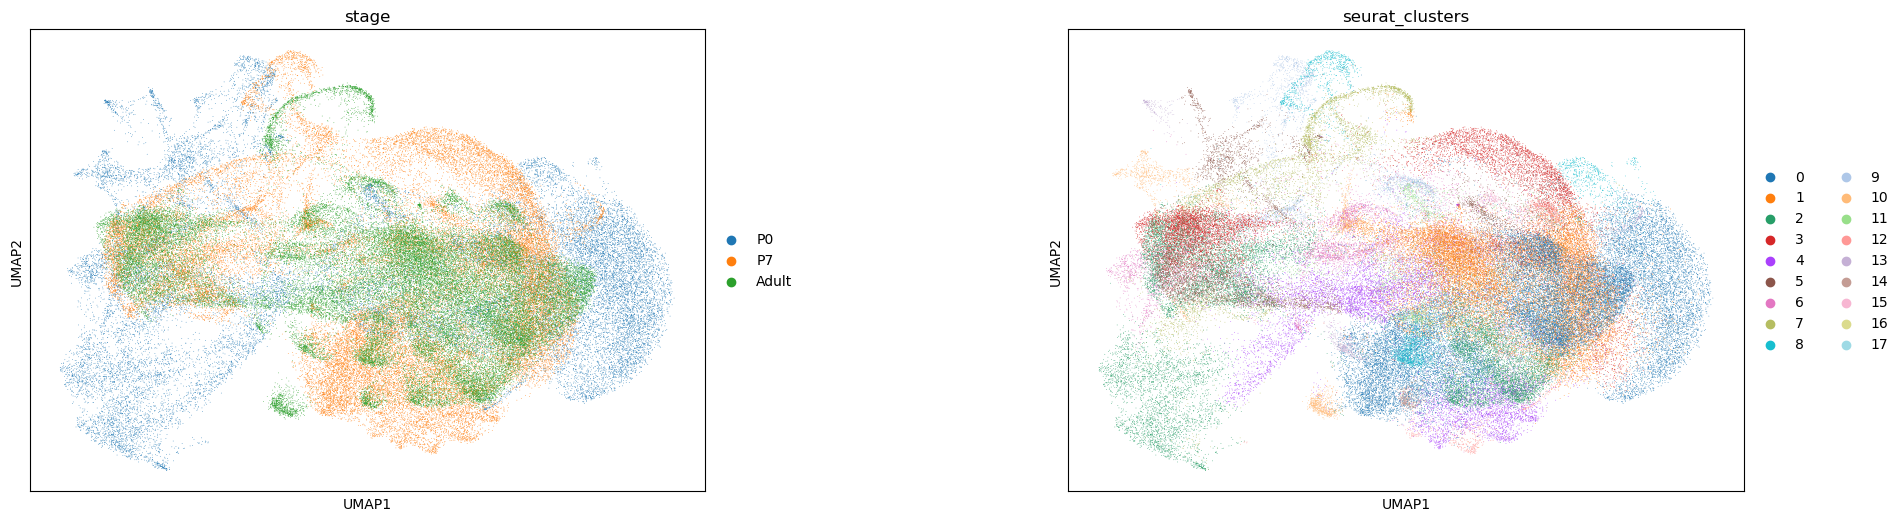

In [27]:
with plt.rc_context({"figure.figsize": (8, 6)}):
    sc.pl.umap(adata, color=["stage", "seurat_clusters"], wspace=0.4)

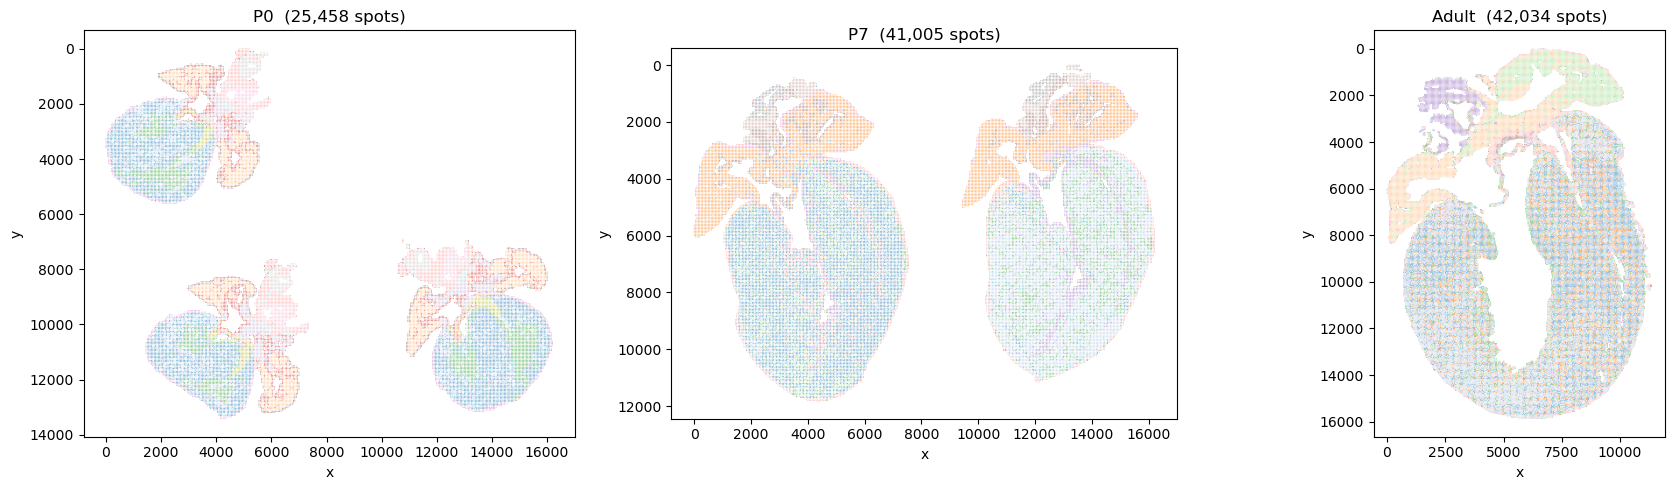

In [29]:
# Spatial maps per stage colored by joint Leiden clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, stage in zip(axes, ["P0", "P7", "Adult"]):
    sub = adata[adata.obs["stage"] == stage]
    coords = sub.obsm["spatial"]
    codes = sub.obs["seurat_clusters"].astype("category").cat.codes
    ax.scatter(coords[:, 0], coords[:, 1], c=codes, cmap="tab20", s=0.3, linewidths=0)
    ax.set_title(f"{stage}  ({sub.n_obs:,} spots)")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## Spatial neighbors (Squidpy)

In [30]:
sq.gr.spatial_neighbors(adata, library_key="stage", coord_type="generic", delaunay=True)

## Optional save

In [33]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if WRITE_OUTPUT:
    adata.write_h5ad(OUTPUT_PATH)
    print(f"Wrote: {OUTPUT_PATH}")
else:
    print(f"WRITE_OUTPUT is False — set to True to save.")
    print(f"Planned output: {OUTPUT_PATH}")

Wrote: /Users/chrislangseth/work/karolinska_institutet/projects/KaroSpaceDataWrangling/data/processed/dev-heart/dev_heart_combined.h5ad


In [ ]:
adata